# Bayesian Classifier — Gaussian Naive Bayes

**Dataset**: Iris — 150 samples, 4 features, 3 classes  
**Objective**: Demonstrate the effectiveness of a Bayesian (Naive Bayes) classifier and estimate its accuracy using cross-validation.

### Bayes' Theorem
$$P(C_k \mid \mathbf{x}) \propto P(\mathbf{x} \mid C_k)\; P(C_k)$$

| Term | Meaning |
|---|---|
| $P(C_k)$ | **Prior** — class probability before seeing data |
| $P(\mathbf{x} \mid C_k)$ | **Likelihood** — probability of features given class $k$ |
| $P(C_k \mid \mathbf{x})$ | **Posterior** — updated class probability given features |

The **naive** assumption: all features are conditionally independent given the class.

| Section | Description |
|---|---|
| 1 | Data Loading & Exploration |
| 2 | Train / Test Split |
| 3 | Gaussian Naive Bayes Model |
| 4 | Prior & Likelihood Inspection |
| 5 | Evaluation Measures |
| 6 | Cross-Validation — Accuracy Estimation |
| 7 | ROC / AUC Curves |

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

print('All imports successful.')

All imports successful.


## 1. Data Loading & Exploration

In [20]:
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
class_names = data.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [class_names[i] for i in y]

print('Shape          :', X.shape)
print('Features       :', list(feature_names))
print('Classes        :', list(class_names))
print('\nClass distribution:')
print(df['species'].value_counts())
print('\nDescriptive statistics:')
df.drop('species', axis=1).describe().round(2)

Shape          : (150, 4)
Features       : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes        : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


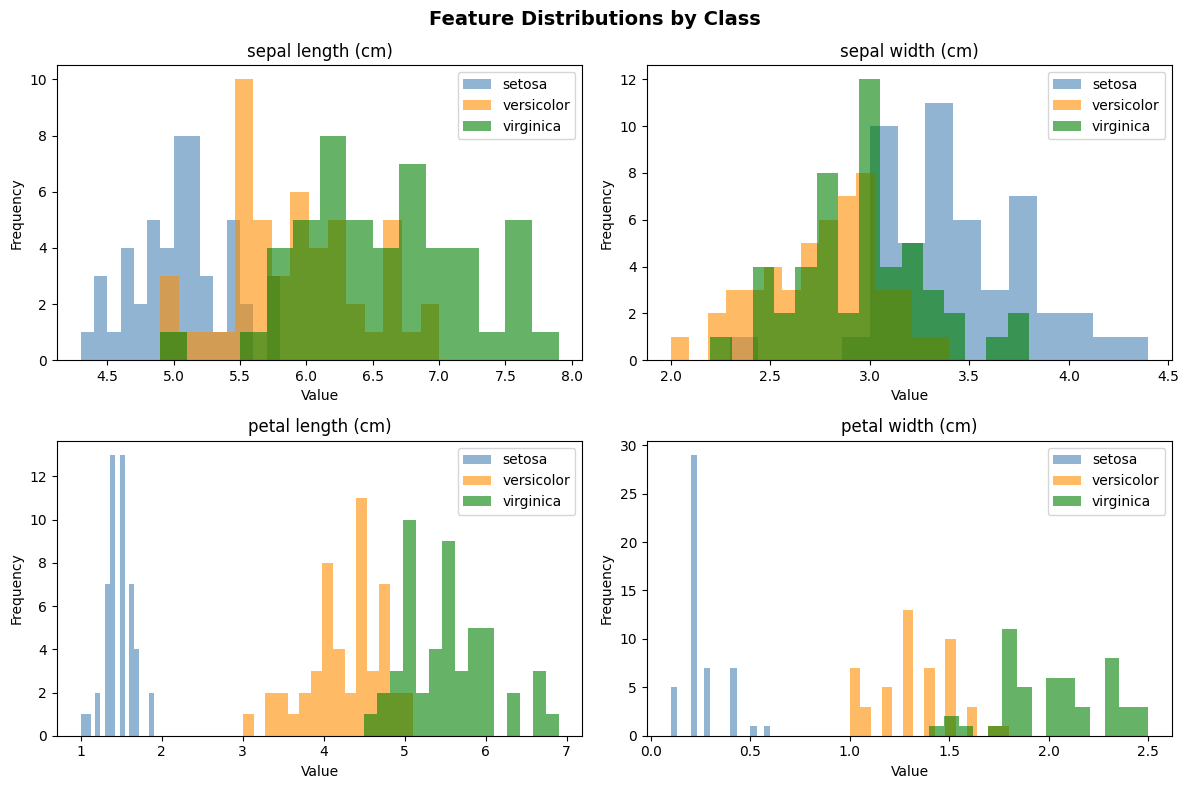

In [21]:
# Feature distributions per class
colors = ['steelblue', 'darkorange', 'green']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, feature in enumerate(feature_names):
    ax = axes[idx // 2][idx % 2]
    for i, cls in enumerate(class_names):
        ax.hist(df[df['species'] == cls][feature], bins=15,
                alpha=0.6, color=colors[i], label=cls)
    ax.set_title(feature)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Train / Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 105
Testing  samples : 45


## 3. Gaussian Naive Bayes Model

**GaussianNB** models each feature $x_i$ for class $C_k$ as a Gaussian distribution:
$$P(x_i \mid C_k) = \frac{1}{\sqrt{2\pi\sigma_{ki}^2}} \exp\!\left(-\frac{(x_i - \mu_{ki})^2}{2\sigma_{ki}^2}\right)$$

It learns $\mu_{ki}$ (mean) and $\sigma_{ki}^2$ (variance) for every feature–class pair from training data.

In [23]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

print('GaussianNB trained successfully.')
print(f'Classes : {gnb.classes_}')
print(f'Priors  : {gnb.class_prior_.round(4)}')

GaussianNB trained successfully.
Classes : [0 1 2]
Priors  : [0.3333 0.3333 0.3333]


## 4. Prior & Likelihood Inspection

The prior probabilities and per-feature Gaussian parameters are the core of the model.

In [24]:
means = gnb.theta_          # shape: (n_classes, n_features)
stds  = np.sqrt(gnb.var_)   # shape: (n_classes, n_features)

print('Learned Means (mu) per class:')
print(pd.DataFrame(means, index=class_names, columns=feature_names).round(3))
print('\nLearned Std Devs (sigma) per class:')
print(pd.DataFrame(stds,  index=class_names, columns=feature_names).round(3))

Learned Means (mu) per class:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                  4.989             3.426              1.486   
versicolor              5.949             2.731              4.237   
virginica               6.683             3.009              5.631   

            petal width (cm)  
setosa                 0.240  
versicolor             1.309  
virginica              2.069  

Learned Std Devs (sigma) per class:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                  0.321             0.417              0.151   
versicolor              0.491             0.293              0.460   
virginica               0.652             0.343              0.568   

            petal width (cm)  
setosa                 0.096  
versicolor             0.189  
virginica              0.253  


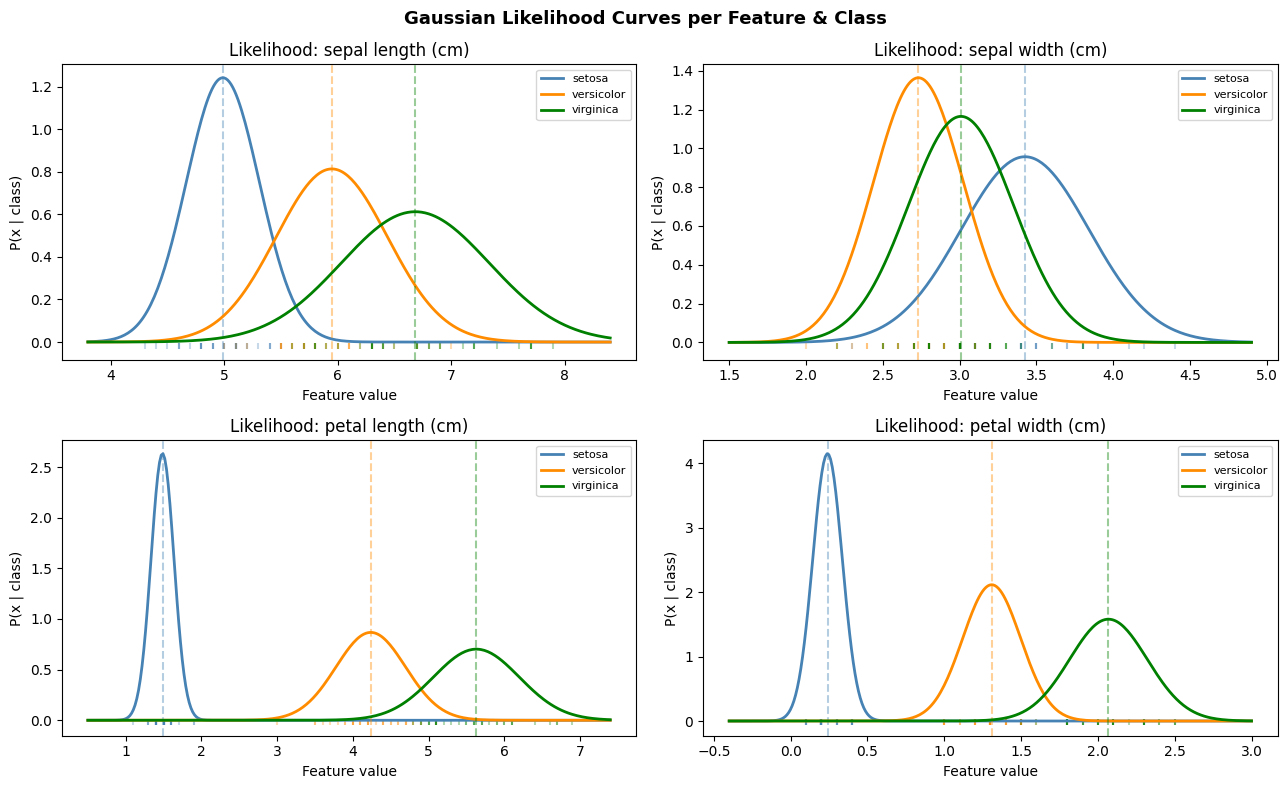

In [7]:
# Gaussian likelihood curves — what the model "knows" about each feature
colors = ['steelblue', 'darkorange', 'green']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for idx, (feature, ax) in enumerate(zip(feature_names, axes.flat)):
    x_range = np.linspace(X[:, idx].min() - 0.5, X[:, idx].max() + 0.5, 300)
    for k, (cls, color) in enumerate(zip(class_names, colors)):
        pdf = norm.pdf(x_range, loc=means[k, idx], scale=stds[k, idx])
        ax.plot(x_range, pdf, color=color, lw=2, label=cls)
        ax.axvline(means[k, idx], color=color, linestyle='--', alpha=0.4)
        ax.scatter(X_train[y_train == k, idx],
                   np.zeros(np.sum(y_train == k)) - 0.02,
                   color=color, alpha=0.3, s=15, marker='|')
    ax.set_title(f'Likelihood: {feature}')
    ax.set_xlabel('Feature value')
    ax.set_ylabel('P(x | class)')
    ax.legend(fontsize=8)

plt.suptitle('Gaussian Likelihood Curves per Feature & Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Evaluation Measures

| Metric | What it captures |
|---|---|
| **Accuracy** | Overall fraction of correct predictions |
| **Confusion Matrix** | Per-class prediction breakdown |
| **Precision** | Of predicted positives, how many were correct |
| **Recall** | Of actual positives, how many were caught |
| **F1-Score** | Harmonic mean of precision and recall |

Test Accuracy: 0.9111  (91.11%)



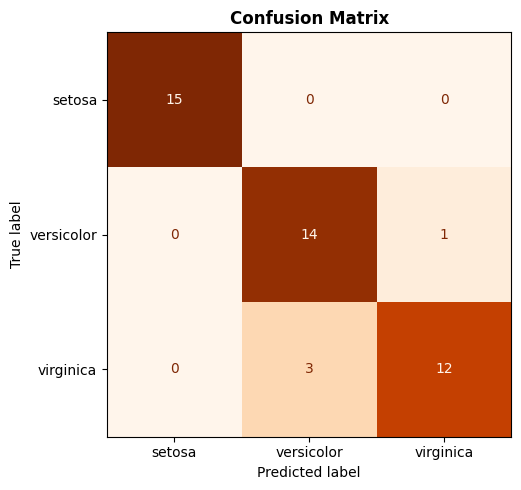

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [25]:
y_pred = gnb.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy:.4f}  ({accuracy * 100:.2f}%)\n')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# Precision / Recall / F1
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))

In [26]:
# Posterior probabilities for the first 10 test samples
y_proba = gnb.predict_proba(X_test)

prob_df = pd.DataFrame(y_proba, columns=class_names).round(4)
prob_df.insert(0, 'Predicted', [class_names[i] for i in y_pred])
prob_df.insert(0, 'Actual',    [class_names[i] for i in y_test])

print('Posterior probabilities — first 10 test samples:')
prob_df.head(10)

Posterior probabilities — first 10 test samples:


,Actual,Predicted,setosa,versicolor,virginica
0,virginica,virginica,0.0,0.0000,1.0000
1,versicolor,versicolor,0.0,0.9955,0.0045
2,virginica,versicolor,0.0,0.8472,0.1528
3,versicolor,versicolor,0.0,0.6680,0.3320
4,virginica,virginica,0.0,0.1036,0.8964
5,virginica,virginica,0.0,0.0000,1.0000
6,versicolor,versicolor,0.0,1.0000,0.0000
7,versicolor,versicolor,0.0,1.0000,0.0000
8,setosa,setosa,1.0,0.0000,0.0000
9,virginica,virginica,0.0,0.0000,1.0000


## 6. Cross-Validation — Accuracy Estimation

A single train/test split may be biased by which samples land in the test set. **Stratified K-Fold CV** gives a stable estimate by:
1. Splitting data into $k$ folds, preserving class proportions
2. Training on $k-1$ folds, testing on the held-out fold — repeated $k$ times
3. Reporting mean ± std of all $k$ accuracy scores

This is the primary way to **estimate** how well the classifier will generalise.

In [27]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(GaussianNB(), X, y, cv=skf, scoring='accuracy')

print('5-Fold Stratified Cross-Validation:')
print(f'  Scores per fold : {cv_scores.round(4)}')
print(f'  Mean accuracy   : {cv_scores.mean():.4f}  ({cv_scores.mean()*100:.2f}%)')
print(f'  Std deviation   : {cv_scores.std():.4f}')
print(f'  95% CI          : [{cv_scores.mean() - 2*cv_scores.std():.4f},',
      f'{cv_scores.mean() + 2*cv_scores.std():.4f}]')

5-Fold Stratified Cross-Validation:
  Scores per fold : [0.9667 0.9667 0.9    1.     0.9   ]
  Mean accuracy   : 0.9467  (94.67%)
  Std deviation   : 0.0400
  95% CI          : [0.8667, 1.0267]


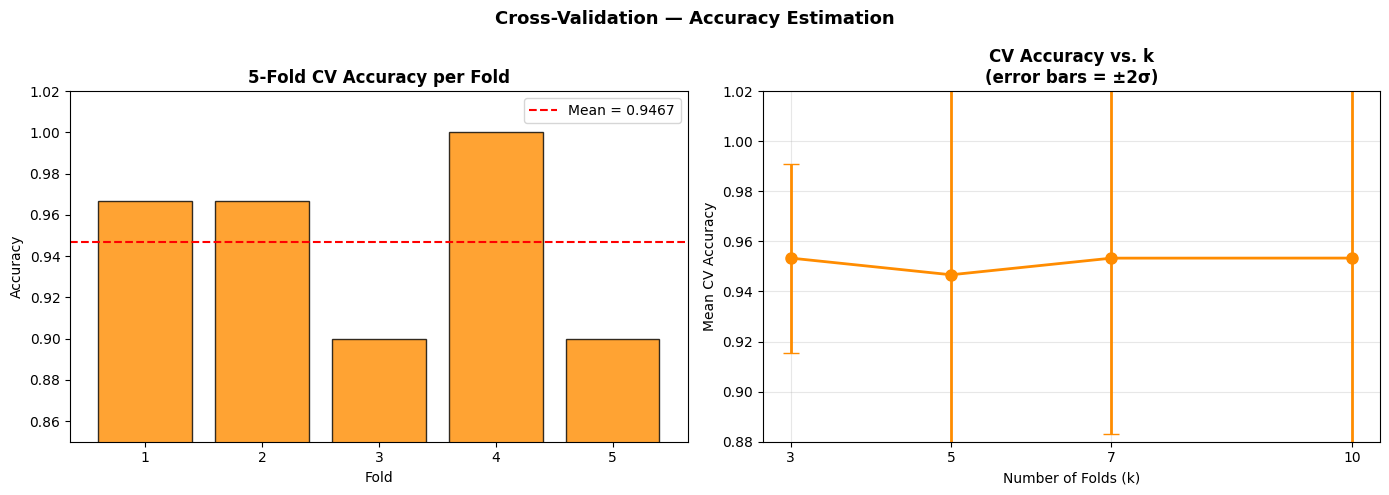

In [28]:
# Compare CV accuracy for different values of k
k_values = [3, 5, 7, 10]
results = {}
for k in k_values:
    scores = cross_val_score(
        GaussianNB(), X, y,
        cv=StratifiedKFold(n_splits=k, shuffle=True, random_state=42),
        scoring='accuracy'
    )
    results[k] = scores

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-fold bar chart for k=5
ax = axes[0]
ax.bar(range(1, 6), cv_scores, color='darkorange', alpha=0.8, edgecolor='black')
ax.axhline(cv_scores.mean(), color='red', linestyle='--',
           label=f'Mean = {cv_scores.mean():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.85, 1.02)
ax.set_title('5-Fold CV Accuracy per Fold', fontweight='bold')
ax.legend()

# Right: mean ± 2σ across k values
ax = axes[1]
means_k = [results[k].mean() for k in k_values]
stds_k  = [results[k].std()  for k in k_values]
ax.errorbar(k_values, means_k, yerr=[2*s for s in stds_k],
            fmt='o-', color='darkorange', capsize=6, lw=2, markersize=8)
ax.set_xlabel('Number of Folds (k)')
ax.set_ylabel('Mean CV Accuracy')
ax.set_ylim(0.88, 1.02)
ax.set_xticks(k_values)
ax.set_title('CV Accuracy vs. k\n(error bars = ±2σ)', fontweight='bold')
ax.grid(alpha=0.3)

plt.suptitle('Cross-Validation — Accuracy Estimation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. ROC / AUC Curves

One-vs-Rest ROC curves measure class discrimination. AUC = 1.0 is perfect; AUC = 0.5 is no better than random.

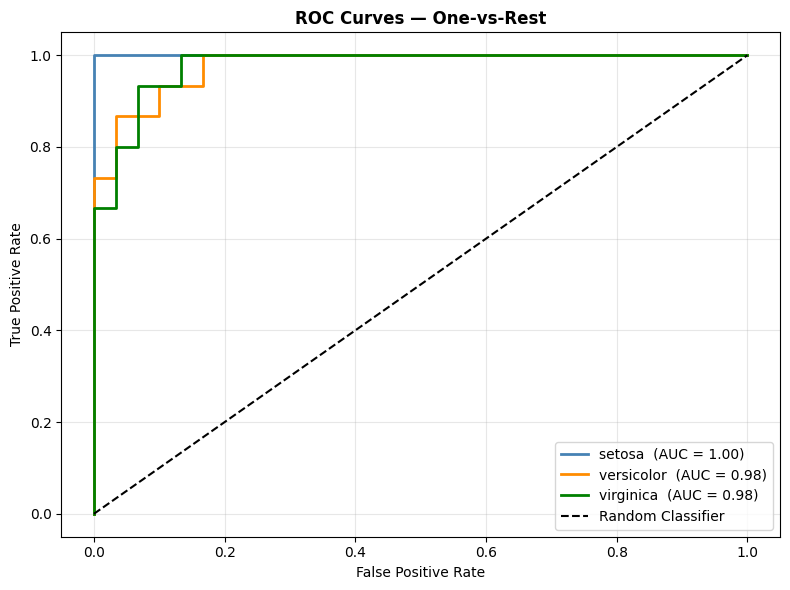

Mean AUC (macro): 0.9852


In [29]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score    = gnb.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['steelblue', 'darkorange', 'green']
auc_scores = []

for i, (cls, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls}  (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-vs-Rest', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mean AUC (macro): {np.mean(auc_scores):.4f}')

## Summary

**Key results** (run all cells to populate exact values):

| Metric | Interpretation |
|---|---|
| Hold-out test accuracy | Single-split estimate — may vary with random seed |
| **5-Fold CV mean accuracy** | Reliable generalisation estimate |
| **5-Fold CV std dev** | Low std → model is stable, not over-fit to one split |
| Mean AUC | Near 1.0 → excellent class separation |

**Why GaussianNB works well on Iris:**
- The per-class feature distributions are approximately Gaussian (visible in Section 4)
- Classes are well-separated in petal length/width (visible in Section 1)
- CV confirms the high accuracy is consistent across all data splits, not a lucky draw